In [ ]:
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from keras.layers import Layer, Input
from keras.layers import Conv2D, Dense, MaxPooling2D, BatchNormalization, Flatten, Dropout, Conv2DTranspose
from keras.preprocessing.image import img_to_array, load_img
from keras.models import Model, Sequential
from keras.layers import Concatenate, UpSampling2D

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/Semantic segmentation dataset'
listDir = []
for dir in os.listdir(path):
    if dir != "classes.json":
        listDir.append(dir)

listDir = sorted(listDir)

In [ ]:
def loadImg(path, dirTile):
    input_img, mask_img = [], []
    path = os.path.join(path, dirTile)
    inpDir, maskDir = os.listdir(path)

    imgDirs = sorted(os.listdir(os.path.join(path, inpDir)))
    mask_imgDirs = sorted(os.listdir(os.path.join(path, maskDir)))

    for imgDir in imgDirs:
        imgDir = os.path.join(path, inpDir, imgDir)
        img = load_img(imgDir, target_size = (224, 224))
        img = tf.convert_to_tensor(img, dtype = tf.float32) / 255.0
        input_img.append(img)

    for mask_imgDir in mask_imgDirs:
        mask_imgDir = os.path.join(path, maskDir, mask_imgDir)
        mask = load_img(mask_imgDir, target_size = (224, 224))
        mask = tf.convert_to_tensor(mask, dtype = tf.float32) / 255.0
        mask_img.append(mask)

    return input_img, mask_img

In [ ]:
def loadData(path = path, listDir = listDir):
    imgs_data, masks_data = [], []
    for dirTile in listDir:
        input_imgs, mask_imgs = loadImg(path, dirTile)

        imgs_data.extend(input_imgs)
        masks_data.extend(mask_imgs)
    return imgs_data, masks_data

In [ ]:
input_imgs, mask_imgs = loadData()

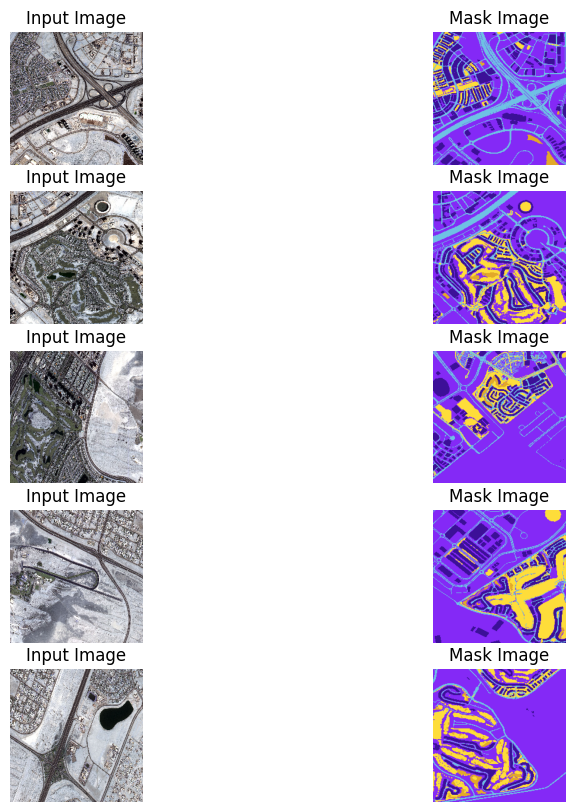

In [ ]:
import matplotlib.pyplot as plt

def display_samples(input_imgs, mask_imgs, num_samples=5):
    plt.figure(figsize=(10, num_samples * 2))

    for i in range(num_samples):
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(input_imgs[i])
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(num_samples, 2, 2*i + 2)
        plt.imshow(mask_imgs[i], cmap="gray")
        plt.title("Mask Image")
        plt.axis("off")

    plt.show()


display_samples(input_imgs, mask_imgs, num_samples=5)


In [ ]:
import numpy as np


split_index = int(0.8 * len(input_imgs))

train_imgs = input_imgs[:split_index]
train_masks = mask_imgs[:split_index]
test_imgs = input_imgs[split_index:]
test_masks = mask_imgs[split_index:]


min_len = min(len(train_imgs), len(train_masks))
train_imgs = train_imgs[:min_len]
train_masks = train_masks[:min_len]


min_len = min(len(test_imgs), len(test_masks))
test_imgs = test_imgs[:min_len]
test_masks = test_masks[:min_len]

train_data = np.array(list(zip(train_imgs, train_masks)))
test_data = np.array(list(zip(test_imgs, test_masks)))



In [ ]:
train_data = np.array(list(zip(train_imgs, train_masks)))
test_data = np.array(list(zip(test_imgs, test_masks)))

In [ ]:
def Conv(x, dropout, filters):
  x = Conv2D(filters = filters, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = BatchNormalization()(x)
  x = Conv2D(filters = filters, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = Dropout(dropout)(x)
  pool = MaxPooling2D(pool_size = (2, 2))(x)

  return x, pool

def UpSample(x, skip_connect, dropout, filters):
  x = Concatenate(axis = -1)([skip_connect, UpSampling2D(size = (2, 2))(x)])
  x = Conv2D(filters = filters, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = Dropout(dropout)(x)
  x = BatchNormalization()(x)
  x = Conv2D(filters = filters, kernel_size = 3, padding = 'same', activation = 'relu')(x)

  return x

In [ ]:
def UNet(x, dropout, conv = [32, 64, 128, 256, 512]):

  # encod
  conv1, pool1 = Conv(x, dropout, conv[0])
  conv2, pool2 = Conv(pool1, dropout, conv[1])
  conv3, pool3 = Conv(pool2, dropout, conv[2])
  conv4, pool4 = Conv(pool3, dropout, conv[3])

  conv5 = Conv2D(filters = conv[4], kernel_size = 3, padding = 'same', activation = 'relu')(pool4)
  conv5 = Dropout(dropout)(conv5)
  conv5 = BatchNormalization()(conv5)

  # decod
  conv6 = UpSample(conv5, conv4, dropout, conv[4])
  conv7 = UpSample(conv6, conv3, dropout, conv[3])
  conv8 = UpSample(conv7, conv2, dropout, conv[2])
  conv9 = UpSample(conv8, conv1, dropout, conv[1])

  # out
  result = Conv2D(filters = 3, kernel_size = 1, padding = 'same', activation = 'sigmoid')(conv9)

  return result

In [ ]:
input = Input(shape = (224, 224, 3))
output = UNet(input, dropout = 0.1)

model = Model(inputs = input, outputs = output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_18 (Conv2D)        │ (None, 224, 224, 32)   │            896 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_9     │ (None, 224, 224, 32)   │            128 │ conv2d_18[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_19 (Conv2D)        │ (None, 224, 224, 32)   │          9,248 │ batch_normalization_9… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_9 (Dropout)       │ (None, 224, 224, 32)   │              0 │ conv2d_19[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 112, 112, 32)   │              0 │ dropout_9[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_20 (Conv2D)        │ (None, 112, 112, 64)   │         18,496 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_10    │ (None, 112, 112, 64)   │            256 │ conv2d_20[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_21 (Conv2D)        │ (None, 112, 112, 64)   │         36,928 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_10 (Dropout)      │ (None, 112, 112, 64)   │              0 │ conv2d_21[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_5           │ (None, 56, 56, 64)     │              0 │ dropout_10[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_22 (Conv2D)        │ (None, 56, 56, 128)    │         73,856 │ max_pooling2d_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_11    │ (None, 56, 56, 128)    │            512 │ conv2d_22[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 56, 56, 128)    │        147,584 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_11 (Dropout)      │ (None, 56, 56, 128)    │              0 │ conv2d_23[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_6           │ (None, 28, 28, 128)    │              0 │ dropout_11[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├──────────────────────

 Total params: 10,970,083 (41.85 MB)

 Trainable params: 10,966,179 (41.83 MB)

 Non-trainable params: 3,904 (15.25 KB)

In [ ]:
model.compile(optimizer = "Adam", loss = "binary_crossentropy", metrics = ["accuracy"])

In [ ]:
history = model.fit(np.array(train_imgs), np.array(train_masks),
                    batch_size = 8,
                    epochs = 5,
                    validation_data = (np.array(test_imgs), np.array(test_masks)))

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 34s 34s/step - accuracy: 0.2568 - loss: 0.7619 - val_accuracy: 0.6561 - val_loss: 0.6900
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.4194 - loss: 0.6881 - val_accuracy: 0.7860 - val_loss: 0.6861
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step - accuracy: 0.7831 - loss: 0.6049 - val_accuracy: 0.8037 - val_loss: 0.6778
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step - accuracy: 0.8693 - loss: 0.5894 - val_accuracy: 0.8021 - val_loss: 0.6623
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step - accuracy: 0.9047 - loss: 0.5738 - val_accuracy: 0.7978 - val_loss: 0.6272


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


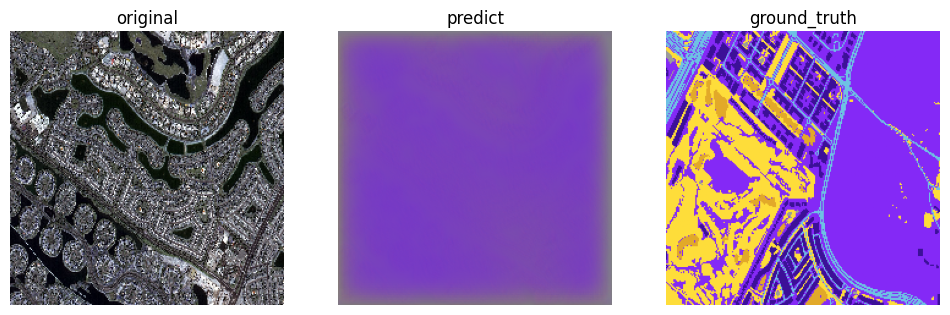

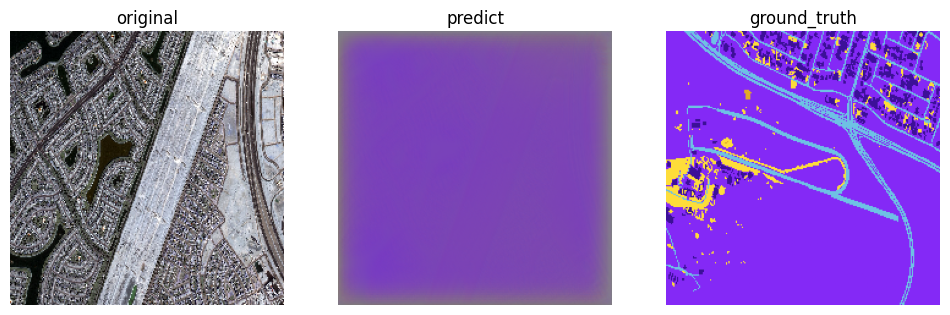

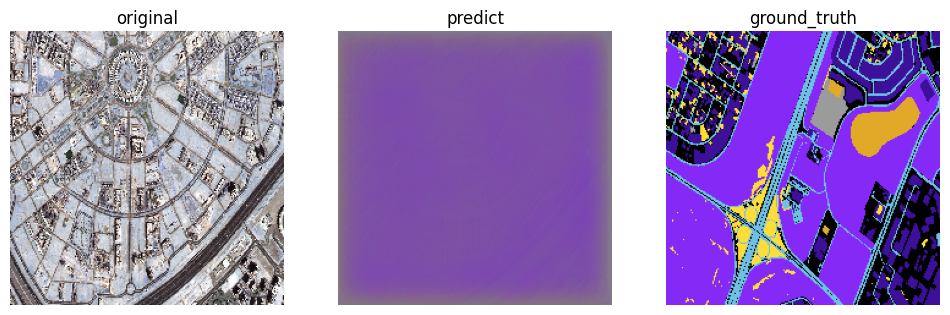

In [ ]:
images_predict = model.predict(np.array(test_imgs))
def show_result(id):
    fig, ax = plt.subplots(1, 3, figsize = (12, 7))

    ax[0].set_title('original')
    ax[0].imshow(test_imgs[id])
    ax[0].axis("off")

    ax[1].set_title('predict')
    ax[1].imshow(images_predict[id])
    ax[1].axis("off")

    ax[2].set_title('ground_truth')
    ax[2].imshow(test_masks[id])
    ax[2].axis("off")


for id in range(len(test_imgs)):
    show_result(id)